# Perspic Analyzer Demo

This notebook demonstrates how to use the `perspic` analyzer to instrument a PyTorch Lightning model.
The analyzer wraps your model and automatically tracks additional metrics (Collective Variables) during training, providing deeper insights into the training dynamics without requiring manual instrumentation.

We will:
1. Setup a standard CIFAR-10 training pipeline.
2. Wrap the model with `analyzer`.
3. Train the model and visualize the additional metrics captured by `perspic`.

**Note:** We set `log_every_n_steps=1` in the `Trainer` to capture high-resolution dynamics for every training step. This allows us to visualize the full noise and convergence behavior of the gradients and coupling coefficient.

In [1]:
import os

import pandas as pd
import pytorch_lightning as pl
import seaborn as sn
import torch
import torchvision
from IPython.display import display
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10

from perspic.analyzer import analyzer
from examples.models import BatchNormMLP, ClassificationModule, WideResNet
from torchvision.models import VisionTransformer
from examples.models.utils import print_model_info

from pytorch_lightning.profilers import SimpleProfiler

import matplotlib.pyplot as plt

pl.seed_everything(7)

PATH_DATASETS = os.environ.get("PATH_DATASETS", ".")
BATCH_SIZE = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = int(os.cpu_count() / 2)

Seed set to 7


In [2]:
# CIFAR10 mean and std
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])

# Load datasets
# We instantiate the dataset twice to apply different transforms to train and val splits
train_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=train_transform)
val_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=test_transform)
test_set = CIFAR10(PATH_DATASETS, train=False, download=True, transform=test_transform)

# Split train/val (45k/5k)
# We use the same seed to ensure the split indices are identical for both dataset instances
generator = torch.Generator().manual_seed(42)
train_set, _ = random_split(train_dataset_full, [45000, 5000], generator=generator)
_, val_set = random_split(val_dataset_full, [45000, 5000], generator=generator)

# DataLoaders
# We set drop_last=True to avoid spikes in gradient norms caused by smaller last batches
train_dataloader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_dataloader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
test_dataloader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)

## Model Instrumentation

Here is the core of `perspic`. Instead of just instantiating your `LightningModule`, you wrap it with the `analyzer` function.
This wrapper injects the necessary hooks to calculate sample-wise metrics (using `functorch` in this example) and logs them automatically.

In [3]:
# Inititalize models

model_vit_large = VisionTransformer(
    image_size=32,
    patch_size=4,
    num_layers=6,
    num_heads=8,
    hidden_dim=256,
    mlp_dim=512,
    num_classes=10,
)
# ~4x smaller (still reasonable for CIFAR-10)
model_vit_medium = VisionTransformer(
    image_size=32,
    patch_size=4,
    num_layers=4,
    num_heads=4,
    hidden_dim=128,
    mlp_dim=256,
    num_classes=10,
)

# Even smaller / "tiny" variant
model_vit_small = VisionTransformer(
    image_size=32,
    patch_size=8,
    num_layers=2,
    num_heads=4,
    hidden_dim=128,
    mlp_dim=256,
    num_classes=10,
)
print_model_info(model_vit_small, verbose=False)
print_model_info(model_vit_medium, verbose=False)
print_model_info(model_vit_large, verbose=False)

print_model_info(WideResNet(28, 160), verbose=False)

Model: VisionTransformer
Number of trainable parameters: 293,514
--------------------------------------------------
Model: VisionTransformer
Number of trainable parameters: 546,186
--------------------------------------------------
Model: VisionTransformer
Number of trainable parameters: 3,195,146
--------------------------------------------------
Model: WideResNet
Number of trainable parameters: 379,248
--------------------------------------------------


In [4]:
# --- Helper Functions for Plotting ---

# Analysis metrics use "analysis_step" to avoid collision with Lightning's "step" column
ANALYSIS_METRICS = {"chi_net", "chi_loss", "loss", "perturbed_loss", "delta_loss", 
                    "batch_size", "coupling", "window_id", "window_center"}

def plot_metric(ax, data, column, label, color, alpha=0.35, ema_span=50, negate=False):
    """
    Plots raw data with transparency and an Exponential Moving Average (EMA) overlay.
    
    Args:
        ax: Matplotlib axes object.
        data: DataFrame containing the metrics.
        column: Name of the column to plot.
        label: Label for the legend.
        color: Color of the plot.
        alpha: Transparency for the raw data.
        ema_span: Span for the EMA calculation.
        negate: If True, plots the negative of the values.
    """
    # Use "analysis_step" for perspic metrics, "step" for Lightning metrics
    step_col = "analysis_step" if column in ANALYSIS_METRICS else "step"
    
    # Fall back to "step" if analysis_step doesn't exist (backward compatibility)
    if step_col == "analysis_step" and step_col not in data.columns:
        step_col = "step"
    
    # Filter and sort data
    subset = data[[column, step_col]].dropna().sort_values(step_col)
    
    # Handle log(0) issue by shifting steps if they start at 0
    steps = subset[step_col]
    if len(steps) > 0 and steps.min() == 0:
        steps = steps + 1
        
    values = subset[column].values
    if negate:
        values = -values
        
    series = pd.Series(values, index=steps)
    
    # Plotting Logic
    if len(series) > 50: 
        # High-frequency data: Plot Raw (noisy) + EMA (smooth)
        ax.plot(series.index, series.values, color=color, alpha=alpha, linewidth=1, label=f"{label} (Raw)")
        ema = series.ewm(span=ema_span).mean()
        ax.plot(series.index, ema.values, color=color, label=f"{label} (EMA)", linewidth=2)
    else:
        # Low-frequency data (e.g. validation): Plot markers
        ax.plot(series.index, series.values, color=color, label=label, marker='o', linestyle='--', linewidth=2)

def configure_axis(ax, title, ylabel, xlabel="Step (log scale)", xscale="log", yscale="linear"):
    """Configures the appearance of a subplot axis."""
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.grid(True, alpha=0.3, which="both")
    # Only add legend if there are labeled artists
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")


def plot_training_metrics(metrics, title=None, figsize=(15, 15), ema_span=50):
    """
    Plot training metrics from a CSV file or DataFrame.
    
    Args:
        metrics: Either a path to a CSV file (str) or a pandas DataFrame containing the metrics.
        title: Optional title for the figure (e.g., model name).
        figsize: Figure size as a tuple (width, height).
        ema_span: Span for the Exponential Moving Average calculation.
    
    Returns:
        fig, axes: The matplotlib figure and axes objects.
    """
    # Load data if path is provided
    if isinstance(metrics, str):
        metrics = pd.read_csv(metrics)
    
    # Display first few rows to show what's being tracked
    print("Tracked Metrics:")
    display(metrics.dropna(axis=1, how="all").head())

    # --- Plotting Configuration ---
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.flatten()
    
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

    # --- Generate Subplots ---

    # Subplot 1: Loss & Accuracy
    ax_loss = axes[0]
    if "train_loss" in metrics.columns:
        plot_metric(ax_loss, metrics, "train_loss", "Train Loss", "blue", ema_span=ema_span)
    if "val_loss" in metrics.columns:
        plot_metric(ax_loss, metrics, "val_loss", "Val Loss", "cyan", ema_span=ema_span)

    configure_axis(ax_loss, "Loss & Accuracy", "Loss")

    # Add Accuracy on secondary axis
    if "train_acc" in metrics.columns or "val_acc" in metrics.columns:
        ax_acc = ax_loss.twinx()
        if "train_acc" in metrics.columns:
            plot_metric(ax_acc, metrics, "train_acc", "Train Acc", "red", ema_span=ema_span)
        if "val_acc" in metrics.columns:
            plot_metric(ax_acc, metrics, "val_acc", "Val Acc", "orange", ema_span=ema_span)
        ax_acc.set_ylabel("Accuracy")
        # Combine legends from both axes
        lines_1, labels_1 = ax_loss.get_legend_handles_labels()
        lines_2, labels_2 = ax_acc.get_legend_handles_labels()
        ax_loss.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")


    # Subplot 2: Gradient Norm (Loss) - chi_loss
    ax_grad_loss = axes[1]
    if "chi_loss" in metrics.columns:
        plot_metric(ax_grad_loss, metrics, "chi_loss", "χ_loss", "purple", ema_span=ema_span)
    configure_axis(ax_grad_loss, "Gradient Norm (Loss)", "χ_loss")


    # Subplot 3: Gradient Norm (Network) - chi_net
    ax_grad_net = axes[2]
    if "chi_net" in metrics.columns:
        plot_metric(ax_grad_net, metrics, "chi_net", "χ_net", "green", ema_span=ema_span)
    configure_axis(ax_grad_net, "Gradient Norm (Network)", "χ_net", yscale="log")


    # Subplot 4: Coupling Coefficient
    ax_coupling = axes[3]
    if "coupling" in metrics.columns:
        plot_metric(ax_coupling, metrics, "coupling", "Coupling", "magenta", ema_span=ema_span)
    configure_axis(ax_coupling, "Coupling Coefficient", "Coupling")


# Subplot 5: Negative Delta Loss
    ax_delta = axes[4]
    if any(name.startswith("lin_loss_delta_eta_") for name in metrics.columns):
        for col in metrics.columns:
            if col.startswith("lin_loss_delta_eta_"):
                plot_metric(ax_delta, metrics, col, "Negative Delta Loss", "brown", negate=True)
    configure_axis(ax_delta, "Negative Delta Loss (Original - Perturbed)", "- Delta Loss", yscale="log")



    # Subplot 6: Unused
    if len(axes) > 5:
        axes[5].axis('off')

    plt.tight_layout()
    plt.show()
    
    return fig, axes

In [5]:
# Wrap the model with the analyzer
# This adds the capability to track additional metrics (like gradients) during training
resnet_model = analyzer(
    lightning_module=ClassificationModule, 
    sample_wise_engine="opacus",
    model=WideResNet(10, 10),
    lr=0.05, 
)

# Define the Trainer
trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/"),
    callbacks=[LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=1,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [6]:
# Train and test the model

trainer.fit(resnet_model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer.test(resnet_model, dataloaders=test_dataloader)

You are using a CUDA device ('NVIDIA GeForce RTX 3090 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | WideResNet | 77.9 K | train
---------------------------------------------
77.9 K    Trainable params
0         Non-trainable params
77.9 K    Total params
0.311     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6408253312110901
        test_loss           1.0583487749099731
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1.0583487749099731, 'test_acc': 0.6408253312110901}]

Tracked Metrics:


,analysis_step,batch_size,chi_loss,chi_net,coupling,epoch,lin_loss_after_eta_1e-03,lin_loss_before_eta_1e-03,lin_loss_delta_eta_1e-03,loss,lr-Adam,step,test_acc,test_loss,train_acc,train_loss,val_acc,val_loss
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,256.0,0.003541,128953.914062,0.000916,0.0,2.334089,2.334507,-0.000418,2.334507,NaN,0,NaN,NaN,0.078125,2.334507,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,1,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,256.0,0.003949,468973.531250,0.011394,0.0,2.799154,2.820255,-0.021100,2.820255,NaN,1,NaN,NaN,0.085938,2.820255,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,2,NaN,NaN,NaN,NaN,NaN,NaN


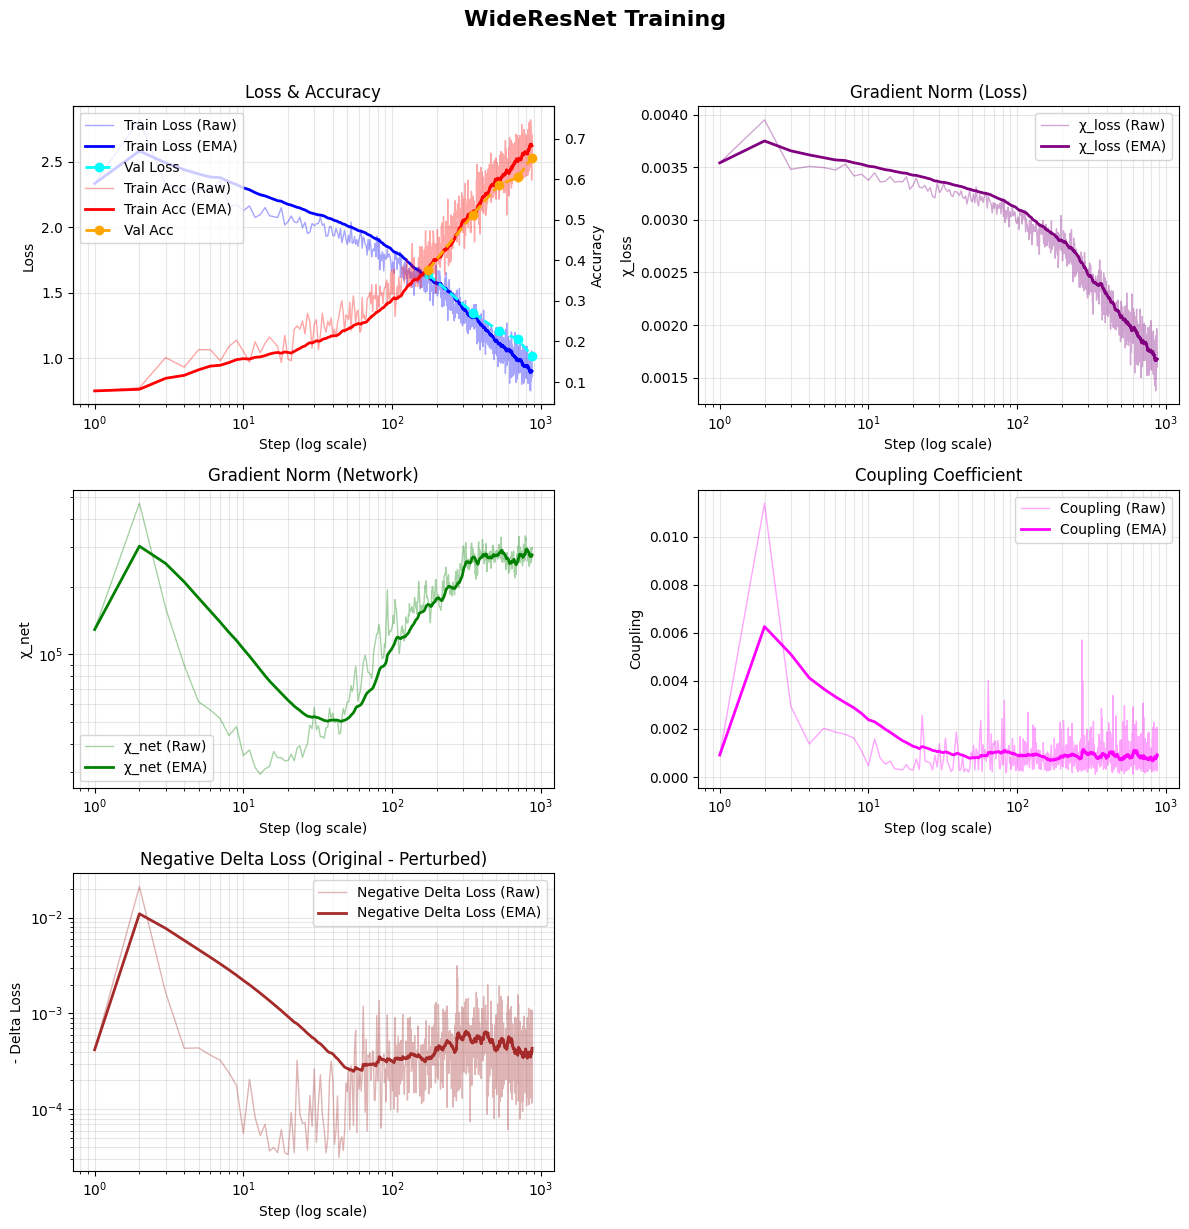

(<Figure size 1200x1200 with 7 Axes>,
 array([<Axes: title={'center': 'Loss & Accuracy'}, xlabel='Step (log scale)', ylabel='Loss'>,
        <Axes: title={'center': 'Gradient Norm (Loss)'}, xlabel='Step (log scale)', ylabel='χ_loss'>,
        <Axes: title={'center': 'Gradient Norm (Network)'}, xlabel='Step (log scale)', ylabel='χ_net'>,
        <Axes: title={'center': 'Coupling Coefficient'}, xlabel='Step (log scale)', ylabel='Coupling'>,
        <Axes: title={'center': 'Negative Delta Loss (Original - Perturbed)'}, xlabel='Step (log scale)', ylabel='- Delta Loss'>,
        <Axes: >], dtype=object))

In [7]:
# Example usage with current trainer
plot_training_metrics(f"{trainer.logger.log_dir}/metrics.csv", title="WideResNet Training", figsize=(12, 12))

### Vision Transformer Example

In [8]:
# vit_model = ClassificationModule(model_vit_medium, lr=0.005,)
vit_model = analyzer(
    lightning_module=ClassificationModule, 
    # sample_wise_engine="functorch", 
    sample_wise_engine="opacus",
    opacus_strict=True,
    model=model_vit_small,
    lr=0.005,
)
trainer = pl.Trainer(
    max_epochs=5,
    # max_steps=2,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/"),
    callbacks=[LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=1,
    # profiler="advanced",
)

trainer.fit(vit_model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer.test(vit_model, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 293 K  | train
----------------------------------------------------
293 K     Trainable params
0         Non-trainable params
293 K     Total params
1.174     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

/data/knikolaou/software/miniconda3/envs/lightning/lib/python3.11/site-packages/torch/autograd/graph.py:823: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_efficient_attention_backward. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:81.)


Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.32912659645080566
        test_loss           1.8163269758224487
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1.8163269758224487, 'test_acc': 0.32912659645080566}]

Tracked Metrics:


,analysis_step,batch_size,chi_loss,chi_net,coupling,epoch,lin_loss_after_eta_1e-03,lin_loss_before_eta_1e-03,lin_loss_delta_eta_1e-03,loss,lr-Adam,step,test_acc,test_loss,train_acc,train_loss,val_acc,val_loss
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,256.0,0.003516,330239.625,0.000917,0.0,2.301520,2.302585,-0.001065,2.302585,NaN,0,NaN,NaN,0.085938,2.302585,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005,1,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,256.0,0.003473,386722.875,0.001106,0.0,2.250448,2.251933,-0.001485,2.251933,NaN,1,NaN,NaN,0.218750,2.251933,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005,2,NaN,NaN,NaN,NaN,NaN,NaN


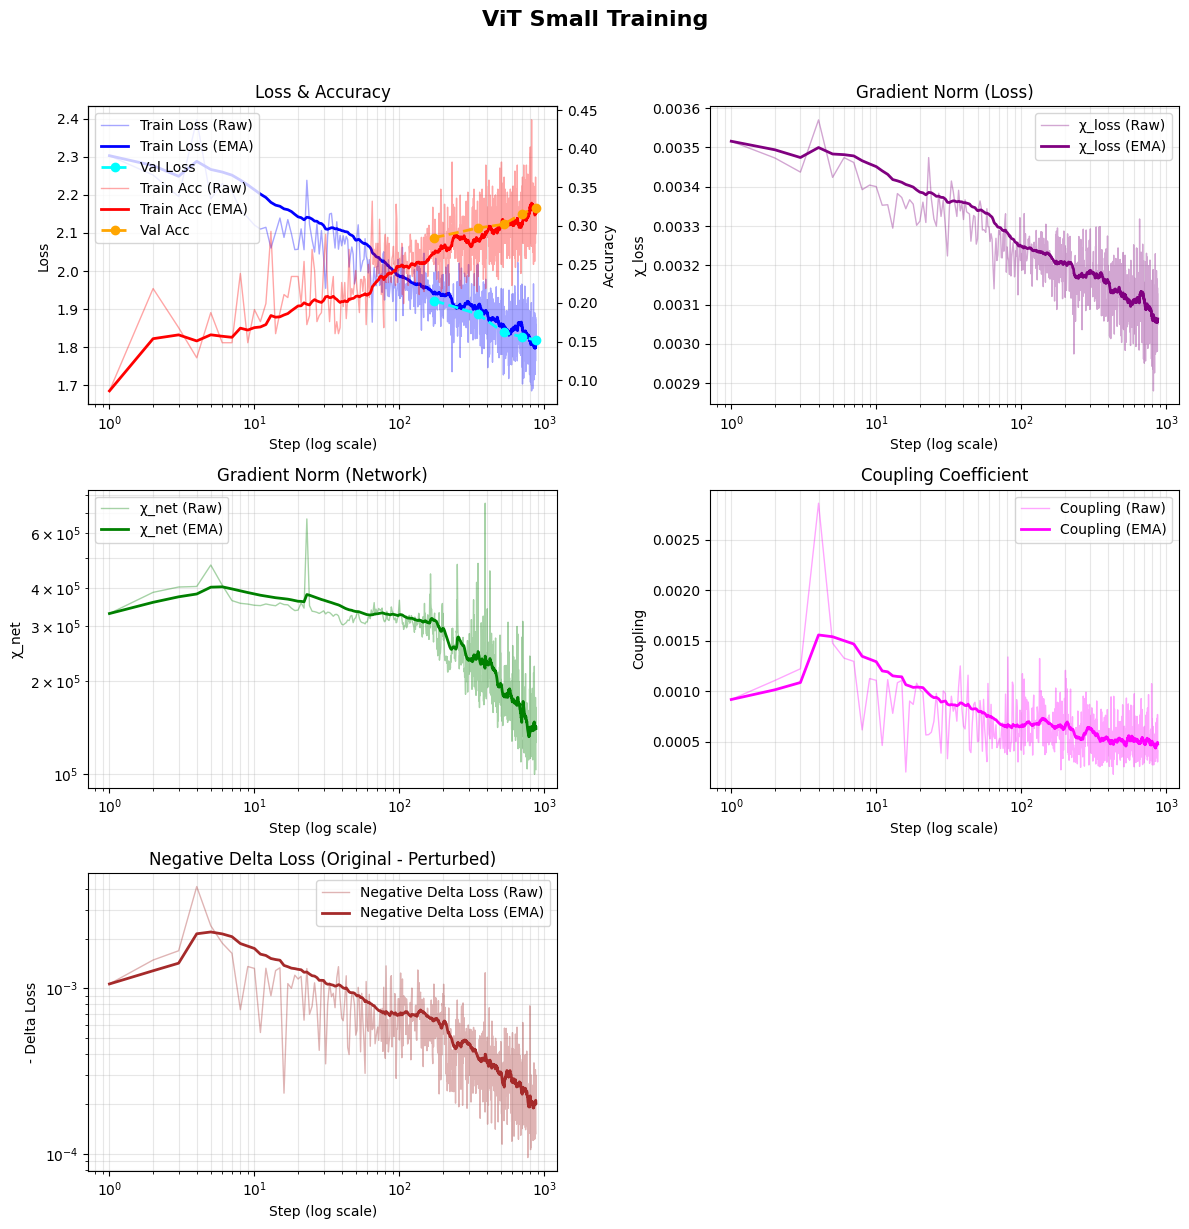

(<Figure size 1200x1200 with 7 Axes>,
 array([<Axes: title={'center': 'Loss & Accuracy'}, xlabel='Step (log scale)', ylabel='Loss'>,
        <Axes: title={'center': 'Gradient Norm (Loss)'}, xlabel='Step (log scale)', ylabel='χ_loss'>,
        <Axes: title={'center': 'Gradient Norm (Network)'}, xlabel='Step (log scale)', ylabel='χ_net'>,
        <Axes: title={'center': 'Coupling Coefficient'}, xlabel='Step (log scale)', ylabel='Coupling'>,
        <Axes: title={'center': 'Negative Delta Loss (Original - Perturbed)'}, xlabel='Step (log scale)', ylabel='- Delta Loss'>,
        <Axes: >], dtype=object))

In [9]:
# Example usage with current trainer
plot_training_metrics(f"{trainer.logger.log_dir}/metrics.csv", title="ViT Small Training", figsize=(12, 12))